In [1]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.4 MB/s eta 0:00:00


# ***Importing Libraries***


In [2]:

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import networkx as nx
from pyvis.network import Network
from community import community_louvain

# Visualization Settings
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')


# Path to EHRShot dataset folder
DATA_DIR = "/content/drive/MyDrive/NAML/"

Mounted at /content/drive


# ***Data Loading***

In [3]:
# File paths
person_path = os.path.join(DATA_DIR, "sampled_person.csv")
condition_path = os.path.join(DATA_DIR, "sampled_condition_occurrence.csv")
measurement_path = os.path.join(DATA_DIR, "sampled_measurement.csv")
concept_path = os.path.join(DATA_DIR, "concept.csv")
observation_path = os.path.join(DATA_DIR, "sampled_observation.csv")

# Data Loading
person_df = pd.read_csv(person_path)
condition_df = pd.read_csv(condition_path, low_memory=False)
measurement_df = pd.read_csv(measurement_path, low_memory=False)
concept_df = pd.read_csv(concept_path, low_memory=False)
observation_df = pd.read_csv(observation_path)

In [4]:
person_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    2000 non-null   int64  
 1   gender_concept_id            2000 non-null   int64  
 2   year_of_birth                2000 non-null   int64  
 3   month_of_birth               2000 non-null   int64  
 4   day_of_birth                 2000 non-null   int64  
 5   birth_DATETIME               2000 non-null   object 
 6   race_concept_id              2000 non-null   int64  
 7   ethnicity_concept_id         2000 non-null   int64  
 8   location_id                  1997 non-null   float64
 9   provider_id                  1790 non-null   float64
 10  care_site_id                 454 non-null    float64
 11  person_source_value          0 non-null      float64
 12  gender_source_value          2000 non-null   object 
 13  gender_source_conc

In [5]:
condition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761822 entries, 0 to 761821
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   condition_occurrence_id        761822 non-null  int64  
 1   person_id                      761822 non-null  int64  
 2   condition_concept_id           761822 non-null  int64  
 3   condition_start_DATE           761822 non-null  object 
 4   condition_start_DATETIME       761822 non-null  object 
 5   condition_end_DATE             16520 non-null   object 
 6   condition_end_DATETIME         16520 non-null   object 
 7   condition_type_concept_id      761822 non-null  int64  
 8   stop_reason                    0 non-null       float64
 9   provider_id                    517481 non-null  float64
 10  visit_occurrence_id            721138 non-null  float64
 11  visit_detail_id                0 non-null       float64
 12  condition_source_value        

In [6]:
measurement_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11944645 entries, 0 to 11944644
Data columns (total 25 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   measurement_id                 int64  
 1   person_id                      int64  
 2   measurement_concept_id         int64  
 3   measurement_DATE               object 
 4   measurement_DATETIME           object 
 5   measurement_time               float64
 6   measurement_type_concept_id    int64  
 7   operator_concept_id            float64
 8   value_as_number                float64
 9   value_as_concept_id            float64
 10  unit_concept_id                float64
 11  range_low                      float64
 12  range_high                     float64
 13  provider_id                    float64
 14  visit_occurrence_id            float64
 15  visit_detail_id                float64
 16  measurement_source_value       object 
 17  measurement_source_concept_id  int64  
 18  

In [7]:
concept_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8263683 entries, 0 to 8263682
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   concept_id        int64  
 1   concept_name      object 
 2   domain_id         object 
 3   vocabulary_id     object 
 4   concept_class_id  object 
 5   standard_concept  object 
 6   concept_code      object 
 7   valid_start_DATE  object 
 8   valid_end_DATE    object 
 9   invalid_reason    object 
 10  load_table_id     object 
 11  load_row_id       float64
dtypes: float64(1), int64(1), object(10)
memory usage: 756.6+ MB


In [8]:
observation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1643088 entries, 0 to 1643087
Data columns (total 21 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   observation_id                 1643088 non-null  int64  
 1   person_id                      1643088 non-null  int64  
 2   observation_concept_id         1643088 non-null  int64  
 3   observation_DATE               1643088 non-null  object 
 4   observation_DATETIME           1643088 non-null  object 
 5   observation_type_concept_id    1643088 non-null  int64  
 6   value_as_number                948812 non-null   float64
 7   value_as_concept_id            1643088 non-null  int64  
 8   qualifier_concept_id           1643088 non-null  int64  
 9   unit_concept_id                727638 non-null   float64
 10  provider_id                    544431 non-null   float64
 11  visit_occurrence_id            1640495 non-null  float64
 12  visit_detail_i

# ***Data Cleaning***

In [9]:
# Drop unnecessary columns from person_df
person_df.drop(columns=['person_source_value', 'trace_id', 'unit_id', 'care_site_id', 'provider_id'], inplace=True)

# Drop unnecessary columns from condition_df
condition_df.drop(columns=['stop_reason', 'visit_detail_id', 'trace_id', 'unit_id'], inplace=True)

# Drop unnecessary columns from measurement_df
measurement_df.drop(columns=['measurement_time', 'operator_concept_id', 'unit_concept_id', 'provider_id',
                             'visit_occurrence_id', 'visit_detail_id', 'modifier_of_event_id', 'modifier_of_field_concept_id',
                             'trace_id', 'unit_id', 'load_table_id', 'value_source_value', 'unit_source_value'], inplace=True)

# Drop unnecessary columns from observation_df
observation_df.drop(columns=['qualifier_concept_id', 'unit_concept_id', 'provider_id', 'visit_occurrence_id',
                             'visit_detail_id', 'qualifier_source_value', 'trace_id', 'unit_id', 'value_as_string',
                             'observation_source_value'], inplace=True)

# Drop unnecessary columns based on your dataset info and common practice
concept_df.drop(columns=['valid_start_DATE', 'valid_end_DATE', 'invalid_reason',
                        'load_table_id', 'load_row_id'], inplace=True)

# Keep essential columns for mapping
# concept_id, concept_name, domain_id, vocabulary_id, concept_class_id, standard_concept, concept_code


# Drop duplicates in all dataframes
person_df.drop_duplicates(inplace=True)
condition_df.drop_duplicates(inplace=True)
measurement_df.drop_duplicates(inplace=True)
observation_df.drop_duplicates(inplace=True)
concept_df.drop_duplicates(inplace=True)

In [10]:
# Filter person_df to only needed columns and convert types
person_filtered = person_df[['person_id', 'gender_concept_id', 'year_of_birth', 'race_concept_id']].copy()
person_filtered['gender_concept_id'] = person_filtered['gender_concept_id'].astype('category')
person_filtered['race_concept_id'] = person_filtered['race_concept_id'].astype('category')

# Filter condition_df for top 100 most common condition_concept_id to reduce size
top_conditions = condition_df['condition_concept_id'].value_counts().nlargest(100).index.tolist()
condition_filtered = condition_df[condition_df['condition_concept_id'].isin(top_conditions)][['person_id', 'condition_concept_id']]

In [11]:
# Filter top 100 measurement concepts similarly as conditions
top_measurements = measurement_df['measurement_concept_id'].value_counts().nlargest(100).index.tolist()
measurement_filtered = measurement_df[measurement_df['measurement_concept_id'].isin(top_measurements)][['person_id', 'measurement_concept_id', 'value_as_number']]

# Convert IDs to category dtype
measurement_filtered['measurement_concept_id'] = measurement_filtered['measurement_concept_id'].astype('category')

# Filter top 100 observation concepts similarly
top_observations = observation_df['observation_concept_id'].value_counts().nlargest(100).index.tolist()
observation_filtered = observation_df[observation_df['observation_concept_id'].isin(top_observations)][['person_id', 'observation_concept_id', 'value_as_number']]

observation_filtered['observation_concept_id'] = observation_filtered['observation_concept_id'].astype('category')

# ***Basic EDA***

/tmp/ipython-input-2953501885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.values, y=condition_labels, palette='viridis')


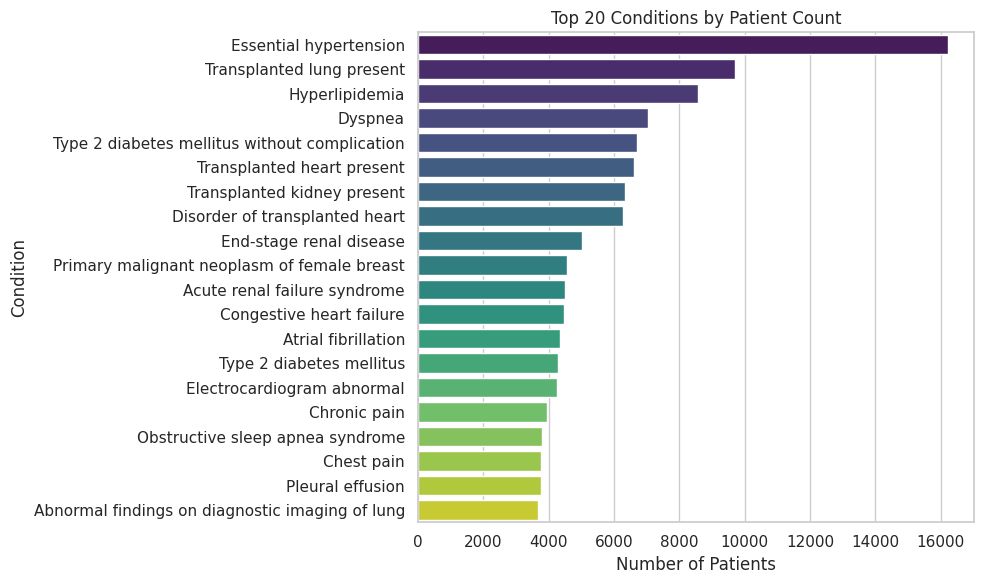

In [12]:
concept_map = concept_df.set_index('concept_id')['concept_name'].to_dict()

# Count patients per condition
condition_counts = condition_filtered['condition_concept_id'].value_counts().head(20)
condition_labels = [concept_map.get(c, str(c)) for c in condition_counts.index]

plt.figure(figsize=(10,6))
sns.barplot(x=condition_counts.values, y=condition_labels, palette='viridis')
plt.title("Top 20 Conditions by Patient Count")
plt.xlabel("Number of Patients")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()

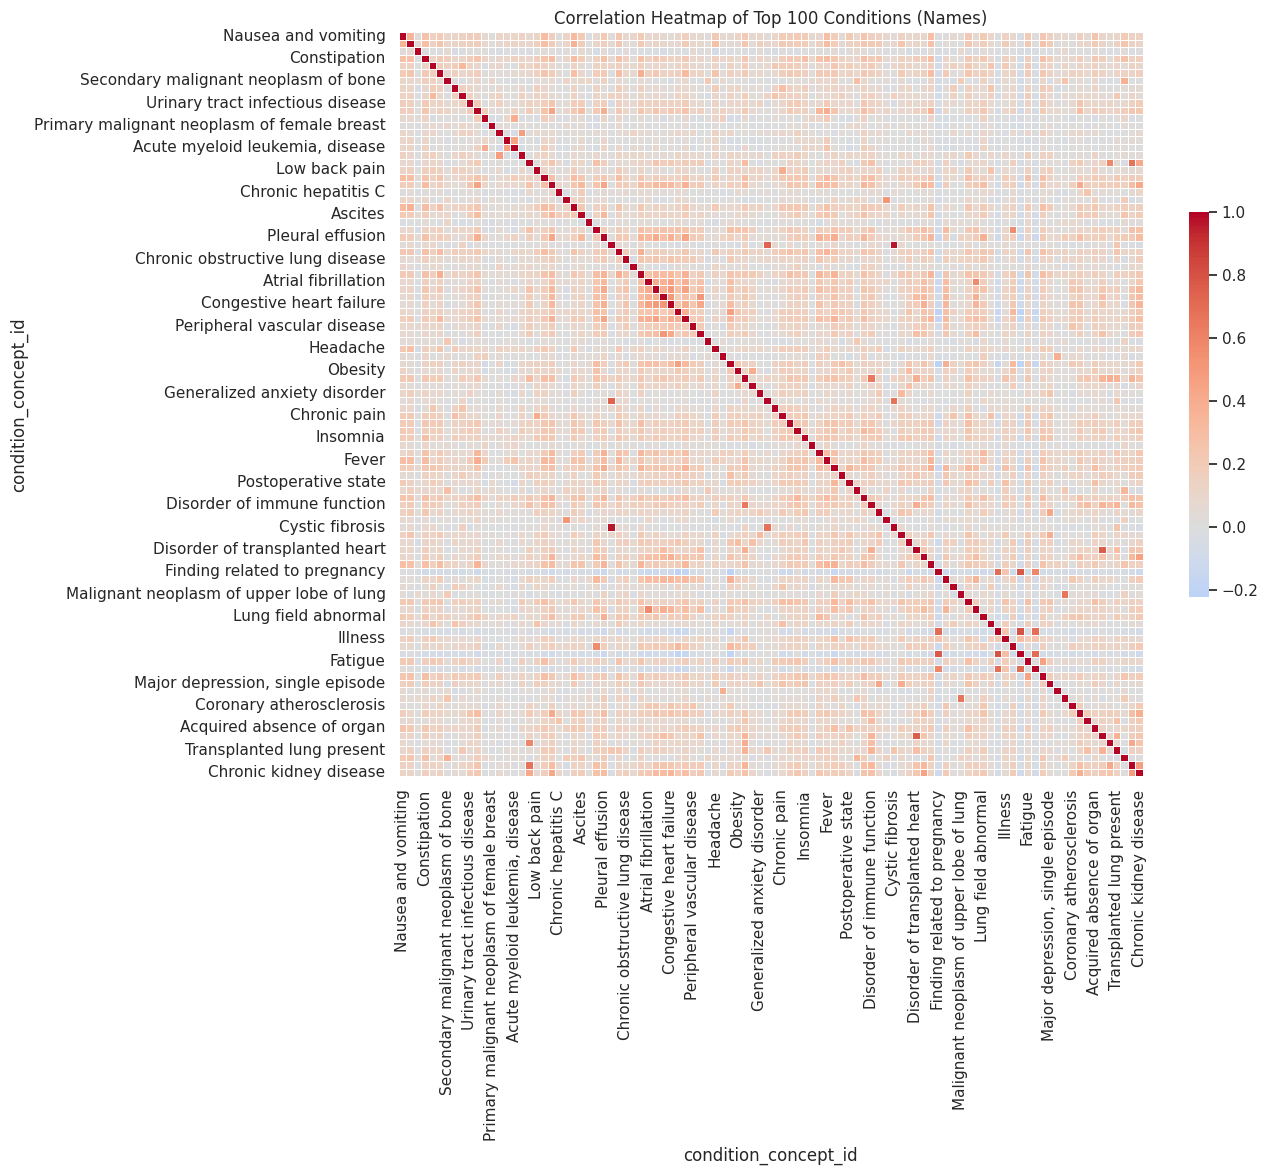

In [13]:
# Create condition presence matrix
condition_matrix = pd.crosstab(condition_filtered['person_id'], condition_filtered['condition_concept_id'])
condition_matrix = condition_matrix.map(lambda x: 1 if x > 0 else 0)

# Map concept IDs to names
concept_map = concept_df.set_index('concept_id')['concept_name'].to_dict()
condition_named = condition_matrix.rename(columns=concept_map)

# Correlation matrix
condition_corr = condition_named.corr()

# Plot heatmap with readable names
plt.figure(figsize=(12, 10))
sns.heatmap(condition_corr, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap of Top 100 Conditions (Names)')
plt.show()

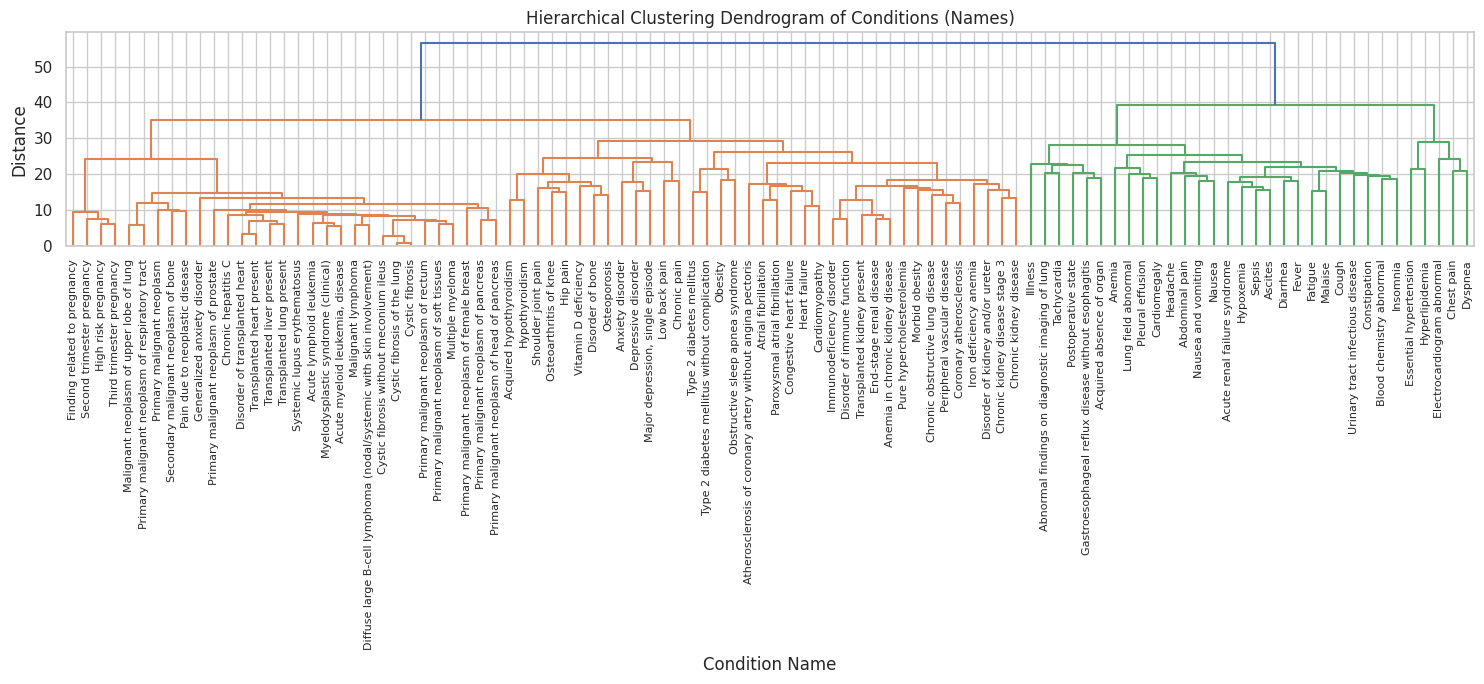

In [14]:
# Perform hierarchical clustering
linkage_matrix = linkage(condition_matrix.T, method='ward')

# Replace IDs with names
labels = [concept_map.get(cid, str(cid)) for cid in condition_matrix.columns]

plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix,
           labels=labels,
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram of Conditions (Names)')
plt.xlabel('Condition Name')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [15]:
print("Available condition names:")
print(condition_named.columns.tolist())

Available condition names:
['Nausea and vomiting', 'Nausea', 'Primary malignant neoplasm of rectum', 'Constipation', 'Disorder of bone', 'Chest pain', 'Secondary malignant neoplasm of bone', 'Shoulder joint pain', 'Osteoporosis', 'Urinary tract infectious disease', 'Sepsis', 'Acute lymphoid leukemia', 'Primary malignant neoplasm of female breast', 'Acquired hypothyroidism', 'Myelodysplastic syndrome (clinical)', 'Acute myeloid leukemia, disease', 'Hypothyroidism', 'End-stage renal disease', 'Low back pain', 'Diarrhea', 'Acute renal failure syndrome', 'Chronic hepatitis C', 'Primary malignant neoplasm of pancreas', 'Abdominal pain', 'Ascites', 'Primary malignant neoplasm of prostate', 'Type 2 diabetes mellitus', 'Pleural effusion', 'Cystic fibrosis of the lung', 'Cough', 'Chronic obstructive lung disease', 'Systemic lupus erythematosus', 'Dyspnea', 'Atrial fibrillation', 'Cardiomegaly', 'Heart failure', 'Congestive heart failure', 'Essential hypertension', 'Electrocardiogram abnormal', 

# ***Network 3: Correlation Network Graph***

In [19]:
# Selected cardiovascular conditions from your available condition names
selected_conditions = [
    'Essential hypertension',
    'Coronary atherosclerosis',
    'Heart failure',
    'Atrial fibrillation',
    'Congestive heart failure'
]

# Create measurement presence matrix
measurement_matrix = pd.crosstab(measurement_filtered['person_id'], measurement_filtered['measurement_concept_id'])
measurement_matrix = measurement_matrix.map(lambda x: 1 if x > 0 else 0)
# Rename columns from concept IDs to names
condition_named = condition_matrix.rename(columns=concept_map)
measurement_named = measurement_matrix.rename(columns=concept_map)

# Filter conditions for the selected cardiovascular conditions actually present
condition_cols = [col for col in condition_named.columns if col in selected_conditions]

# Filter condition matrix for selected conditions
condition_filtered = condition_named.loc[:, condition_cols]

# Keep all measurement (risk factors)
measurement_filtered = measurement_named.copy()

# Combine data - persons by risk factors and selected conditions
combined_df = pd.concat([measurement_filtered, condition_filtered], axis=1).fillna(0)

# Compute correlation matrix
corr_matrix = combined_df.corr()

# Build edges with all positive correlation weights (no threshold)
edges = []
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if j <= i:
            continue
        weight = abs(corr_matrix.iloc[i, j])
        if weight > 0:
            edges.append((col1, col2, weight))

# Build NetworkX graph
G = nx.Graph()

# Add condition nodes as red nodes
for cond in condition_cols:
    G.add_node(cond, label=cond, color='red')

# Add all other nodes as blue (risk factors)
for node in combined_df.columns:
    if node not in condition_cols:
        G.add_node(node, label=node, color='green')

# Add edges with weight attribute
for n1, n2, weight in edges:
    G.add_edge(n1, n2, weight=weight, title=f'Correlation: {weight:.2f}')

# Create PyVis network visualization
net = Network(height='750px', width='100%', bgcolor='white', font_color='black', notebook=True, cdn_resources='in_line')

# Add nodes to network with color and label
for node, data in G.nodes(data=True):
    net.add_node(node, label=data['label'], color=data['color'], fixed={'x': False, 'y': False})

# Add edges with width scaled by correlation weight
for source, target, data in G.edges(data=True):
    width = 1 + 4 * data['weight']
    net.add_edge(source, target, color='yellow', title=data['title'], width=width)
net.force_atlas_2based()

# Save the PyVis network as HTML
net.show('cvd_network_with_selected_conditions.html')

from IPython.core.display import display, HTML
display(HTML("cvd_network_with_selected_conditions.html"))

cvd_network_with_selected_conditions.html


In [20]:
# Calculate centralities
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
pagerank = nx.pagerank(G, weight='weight')

# Community detection
partition = community_louvain.best_partition(G, weight='weight')
nx.set_node_attributes(G, partition, 'community')

# Network density and clustering coefficient
density = nx.density(G)
clustering_coefficient = nx.average_clustering(G, weight='weight')

# Robustness (Assortativity)
assortativity = nx.degree_assortativity_coefficient(G)

# output summary
print(f"\nNetwork density: {density:.4f}")
print(f"\nAverage clustering coefficient: {clustering_coefficient:.4f}")
print(f"\nAssortativity coefficient: {assortativity:.4f}")
print("\nTop 10 nodes by eigenvector centrality:")
top_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, score in top_eigen:
    print(f"{node}: {score:.4f}")


Network density: 1.0006

Average clustering coefficient: 0.2822

Assortativity coefficient: -0.0003

Top 10 nodes by eigenvector centrality:
Leukocytes [#/volume] in Specimen by Automated count: 0.1330
MCHC [Mass/volume] by Automated count: 0.1329
MCH [Entitic mass] by Automated count: 0.1329
Erythrocyte distribution width [Ratio] by Automated count: 0.1329
Erythrocytes [#/volume] in Blood by Automated count: 0.1329
MCV [Entitic volume] by Automated count: 0.1329
Platelets [#/volume] in Blood by Automated count: 0.1326
Hemoglobin [Mass/volume] in Blood: 0.1314
Glucose [Mass/volume] in Serum or Plasma: 0.1314
Sodium [Moles/volume] in Serum or Plasma: 0.1307
